In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy import stats
except Exception:
    stats = None

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_12175/4192345027.py:122: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


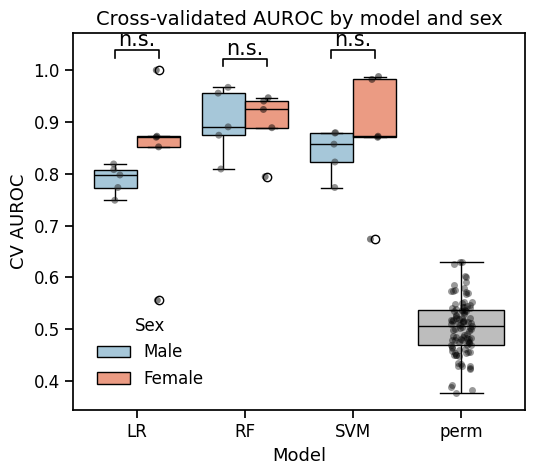

,model,fold,auroc,sex
0,LR,0,0.870536,Female
1,LR,1,1.000000,Female
2,LR,2,0.872428,Female
3,LR,3,0.851852,Female
4,LR,4,0.555556,Female


In [6]:
# Combine CV AUROC results from all models and visualize as boxplot

files = [
    ("output/logreg/cv_auroc_logreg_tox_female.csv", "LR", "Female"),
    ("output/logreg/cv_auroc_logreg_tox_male.csv", "LR", "Male"),
    ("output/random_forest/cv_auroc_rf_tox_female.csv", "RF", "Female"),
    ("output/random_forest/cv_auroc_rf_tox_male.csv", "RF", "Male"),
    ("output/svm/cv_auroc_svm_tox_female.csv", "SVM", "Female"),
    ("output/svm/cv_auroc_svm_tox_male.csv", "SVM", "Male"),
]

# Permutation results (single distribution, no sex stratification)
perm_paths = [
    "output/random_forest/cv_auroc_rf_perm.csv",
    "output/cv_auroc_rf_perm.csv",
    "output/logreg/cv_auroc_rf_perm.csv",
]

perm_df = None
for p in perm_paths:
    try:
        perm_df = pd.read_csv(p)
        break
    except Exception:
        continue

if perm_df is None:
    raise FileNotFoundError(f"Permutation AUROC CSV not found. Tried: {perm_paths}")

perm_df = perm_df.copy()
perm_df["model"] = "perm"
perm_df["sex"] = "Perm"


dfs = []
for path, model_label, sex_label in files:
    df = pd.read_csv(path)
    df["model"] = model_label
    df["sex"] = sex_label
    dfs.append(df)

dfs.append(perm_df)
cv_all = pd.concat(dfs, ignore_index=True)

# Orders / styling
model_order_all = ["LR", "RF", "SVM", "perm"]
model_order_sex = ["LR", "RF", "SVM"]
sex_order = ["Male", "Female"]
palette = {"Male": "#9ecae1", "Female": "#fc9272"}

font_scale = 1.25
sns.set_context(
    "notebook",
    font_scale=font_scale,
    rc={
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
    },
)


def p_to_stars(p: float) -> str:
    if p is None or np.isnan(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def paired_pvalue(df: pd.DataFrame, model: str):
    if stats is None:
        return None

    d = df[(df["model"] == model) & (df["sex"].isin(["Male", "Female"]))]
    pivot = d.pivot_table(index="fold", columns="sex", values="auroc", aggfunc="mean")
    if ("Male" not in pivot.columns) or ("Female" not in pivot.columns):
        return None

    pivot = pivot[["Male", "Female"]].dropna()
    if pivot.shape[0] < 2:
        return None

    try:
        res = stats.wilcoxon(
            pivot["Male"].values,
            pivot["Female"].values,
            alternative="two-sided",
            zero_method="wilcox",
        )
    except ValueError:
        return None

    return float(res.pvalue)


def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", color="black")


plt.figure(figsize=(5.6, 5))
ax = sns.boxplot(
    data=cv_all[cv_all["model"].isin(model_order_sex)],
    x="model",
    y="auroc",
    hue="sex",
    order=model_order_all,
    hue_order=sex_order,
    palette=palette,
    linecolor="black",
    linewidth=1.0,
)

sns.stripplot(
    data=cv_all[cv_all["model"].isin(model_order_sex)],
    x="model",
    y="auroc",
    hue="sex",
    order=model_order_all,
    hue_order=sex_order,
    dodge=True,
    color="black",
    alpha=0.5,
    ax=ax,
)

# Add permutation box (grey)
sns.boxplot(
    data=cv_all[cv_all["model"] == "perm"],
    x="model",
    y="auroc",
    order=model_order_all,
    color="#bdbdbd",
    linecolor="black",
    linewidth=1.0,
    ax=ax,
)

sns.stripplot(
    data=cv_all[cv_all["model"] == "perm"],
    x="model",
    y="auroc",
    order=model_order_all,
    color="black",
    alpha=0.4,
    ax=ax,
)

# Fix legend (stripplot adds duplicates) and place it bottom-left
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[: len(sex_order)],
    labels[: len(sex_order)],
    title="Sex",
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
)

# Statistical annotations (Male vs Female per model, paired by fold)
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
bracket_h = 0.02 * y_range

for i, model in enumerate(model_order_sex):
    p = paired_pvalue(cv_all, model)
    label = p_to_stars(p)

    d = cv_all[(cv_all["model"] == model) & (cv_all["sex"].isin(["Male", "Female"]))]
    if d.empty:
        continue

    y = float(d["auroc"].max()) + 0.06 * y_range
    y = min(y, y_max - 0.01 * y_range)

    x_center = model_order_all.index(model)
    x1 = x_center - 0.2
    x2 = x_center + 0.2

    add_sig_bracket(ax, x1, x2, y, bracket_h, label)

plt.ylabel("CV AUROC")
plt.xlabel("Model")
plt.title("Cross-validated AUROC by model and sex")

plt.tight_layout()
plt.savefig("output/cv_auroc_boxplot_tox_by_sex.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/cv_auroc_boxplot_tox_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()

cv_all.head()